# C06 — k-Space Parallel Imaging: SMASH & GRAPPA
### MRI: Zero to Hero · Module 4 (Advanced Reconstruction) · Day 26

> *Source lecture:* **Computational MRI — "Parallel Imaging II: k-space methods"** (FAU Erlangen / NYU)
> *Companion notes:* `C06_summary.md`

In the previous lecture (**SENSE**, C05) we undid aliasing **in image space** by solving, pixel-by-pixel,
a small system of equations using the coil sensitivities. This time we stay in **k-space**: instead of
unwrapping an aliased image, we **synthesise the k-space lines we never acquired** directly from the lines
we *did* acquire, using all coils at once.

Two methods:
* **SMASH** (Sodickson 1997) — the historical idea: combine coil sensitivities to *build a spatial harmonic*
  $e^{-i\,m\,\Delta k_y y}$, which is exactly a shift in k-space.
* **GRAPPA** (Griswold 2002) — the practical generalisation everyone actually uses: a *coil-by-coil*,
  data-driven k-space interpolation that needs **no explicit coil-sensitivity maps**.

**The single sentence to remember — *when do you run the IFFT?***
> **SENSE** → IFFT *first* (get an aliased image), *then* compute. **GRAPPA** → compute *first*
> (fill k-space), *then* IFFT. Same physics, opposite order of operations.

**What you'll build in this notebook**
1. See undersampling create aliasing, and watch the multi-coil array hand us the extra information.
2. Reproduce the **SMASH** spatial-harmonic idea (and feel *why* it is fragile).
3. Implement **GRAPPA** from scratch — calibration ($T = S\,w$), missing-line synthesis, coil combination.
4. Work the **Lab 6 exercise** end-to-end (R, kernel size, ACS lines, PSNR/SSIM, comparison to SENSE) with answers.

> All data here is a **synthetic phantom + simulated coils**, so the notebook runs in seconds with no downloads.
> The final section shows how to swap in the real `data_brain_8coils.mat` from the lab.

## 0 · Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import resize
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

rng = np.random.default_rng(0)
plt.rcParams.update({"image.cmap": "gray", "figure.dpi": 110})

# ---- Centered 2D FFT pair (k-space <-> image). Always use these. ----
def fft2c(x):
    return np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(x, axes=(-2, -1)), axes=(-2, -1)), axes=(-2, -1))

def ifft2c(k):
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(k, axes=(-2, -1)), axes=(-2, -1)), axes=(-2, -1))

def sos(coil_imgs):
    "Sum-of-squares coil combination -> magnitude image."
    return np.sqrt(np.sum(np.abs(coil_imgs) ** 2, axis=0))

def nrm(a):
    "Normalise to [0,1] for fair PSNR/SSIM."
    return a / a.max()

## 1 · The problem — undersampling makes aliasing

We accelerate by **skipping phase-encode lines** in k-space. Keeping every $R$-th line along $k_y$ shrinks the
field of view to $\text{FOV}/R$ in image space, so the object **wraps onto itself** — classic aliasing.

This is the same picture as slides 3–4 of the lecture: full sampling → clean image; $2\Delta k_y$ → two
overlapping copies.

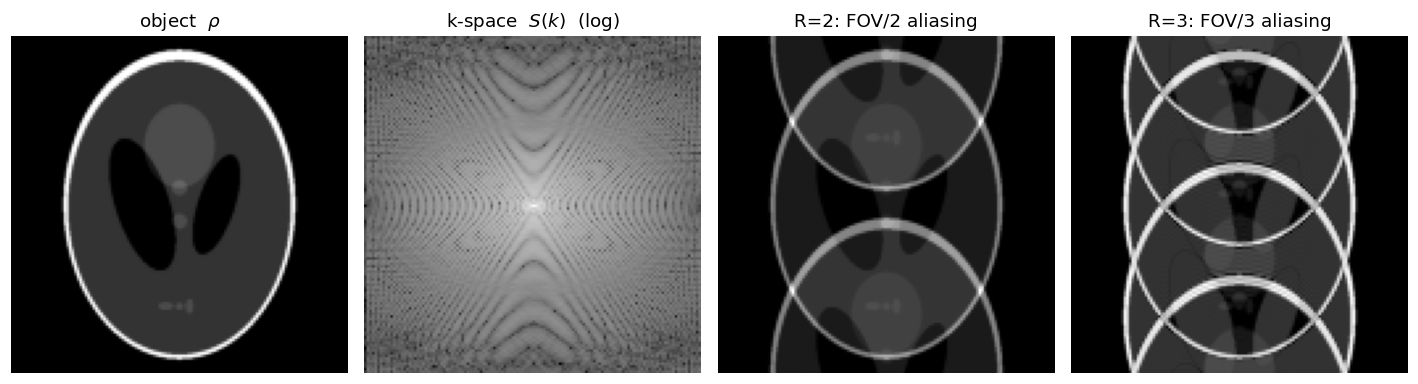

In [2]:
N = 128
phantom = resize(shepp_logan_phantom(), (N, N), anti_aliasing=True).astype(np.complex128)
ksp = fft2c(phantom)                      # single-coil k-space

fig, ax = plt.subplots(1, 4, figsize=(13, 3.4))
ax[0].imshow(np.abs(phantom)); ax[0].set_title("object  $\\rho$")
ax[1].imshow(np.log(np.abs(ksp) + 1e-3)); ax[1].set_title("k-space  $S(k)$  (log)")
for j, R in enumerate([2, 3]):
    us = np.zeros_like(ksp); us[::R, :] = ksp[::R, :]     # keep every R-th k_y line
    ax[2 + j].imshow(np.abs(ifft2c(us)))
    ax[2 + j].set_title(f"R={R}: FOV/{R} aliasing")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

Phase-encoding $k_y$ runs vertically here, so the wrap-around appears top-to-bottom. With a **single coil**
this information is simply lost. The whole game of parallel imaging is to recover it from somewhere else —
namely, **multiple receiver coils**.

## 2 · Multi-coil acquisition — where the extra information lives

A surface-coil array gives $N_c$ receive channels (lecture: 8). Each coil "sees" the object multiplied by its
own smooth **sensitivity map** $C_\ell(\mathbf r)$:

$$ \text{coil image}_\ell(\mathbf r) = C_\ell(\mathbf r)\,\rho(\mathbf r). $$

The same physics in the two domains (lecture slide 10 / 28):

| domain | object × sensitivity | operation |
|---|---|---|
| **image** | $C_\ell(\mathbf r)\,\rho(\mathbf r)$ | **multiplication** |
| **k-space** | $\hat C_\ell(\mathbf k) \;\ast\; \hat\rho(\mathbf k)$ | **convolution** |

That last row — *multiplication in image space = convolution in k-space* — is the **core principle of GRAPPA**.
Because $\hat C_\ell$ is concentrated near the k-space centre (sensitivities are smooth → only low frequencies),
the convolution is **local**: a coil-image k-space point is a short, weighted blend of nearby object k-space
points. GRAPPA simply *learns* those weights.

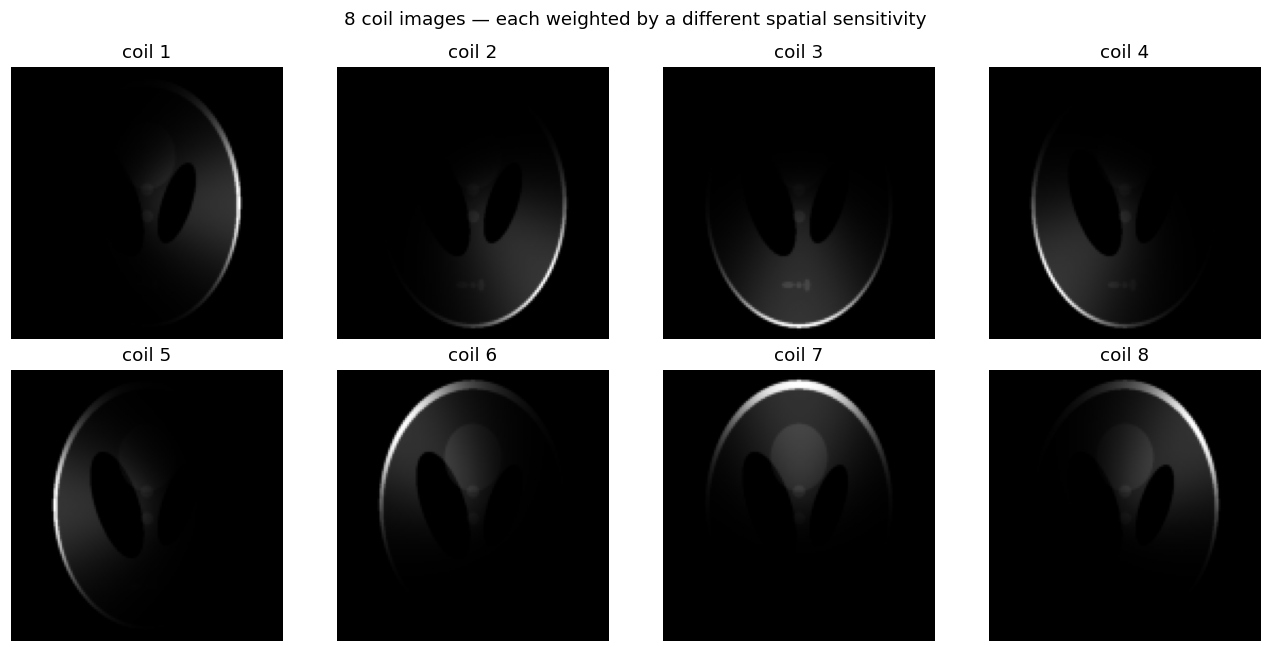

Reference image built: (128, 128)


In [3]:
def make_coils(N=128, ncoils=8, fov_frac=1.6):
    "Smooth complex sensitivities for a circular array of `ncoils` surface coils."
    yy, xx = np.mgrid[0:N, 0:N].astype(float)
    yy = (yy - N / 2) / (N / 2); xx = (xx - N / 2) / (N / 2)
    C = np.zeros((ncoils, N, N), dtype=np.complex128)
    for c in range(ncoils):
        ang = 2 * np.pi * c / ncoils
        cy, cx = fov_frac * np.sin(ang), fov_frac * np.cos(ang)
        mag = np.exp(-((yy - cy) ** 2 + (xx - cx) ** 2) / (2 * 0.55 ** 2))
        phase = np.exp(1j * 2.0 * (xx * np.cos(ang) + yy * np.sin(ang)))
        C[c] = mag * phase
    s = np.sqrt(np.sum(np.abs(C) ** 2, 0)); s[s < 1e-8] = 1
    return C / s

Nc = 8
C = make_coils(N, Nc)
coil_imgs = C * phantom            # (Nc, N, N)
ksp_full  = fft2c(coil_imgs)       # fully-sampled multi-coil k-space (our ground-truth acquisition)

fig, ax = plt.subplots(2, 4, figsize=(12, 6))
for c in range(8):
    ax[c // 4, c % 4].imshow(np.abs(coil_imgs[c])); ax[c // 4, c % 4].axis("off")
    ax[c // 4, c % 4].set_title(f"coil {c+1}")
plt.suptitle("8 coil images — each weighted by a different spatial sensitivity"); plt.tight_layout(); plt.show()

ref = sos(ifft2c(ksp_full))        # reference (fully-sampled SoS) used for all metrics below
print("Reference image built:", ref.shape)

## 3 · SMASH — building spatial harmonics from coil sensitivities

SMASH's insight: a **missing** k-space line at $k_y + m\,\Delta k_y$ is the acquired line $k_y$ **modulated** by
$e^{-i m \Delta k_y y}$ (a *spatial harmonic* of order $m$). By the Fourier shift theorem, multiplying the image
by that harmonic *shifts* its k-space by $m\,\Delta k_y$ — i.e. it manufactures the skipped line.

We can't physically multiply by a harmonic, but we *can* try to **synthesise** it as a weighted sum of the coil
sensitivities (lecture slides 24–25):

$$ \sum_{\ell=1}^{N_c} w_\ell^{(m)}\, C_\ell(y)\;\approx\; e^{-i\,m\,\Delta k_y\, y}. $$

If such weights $w_\ell^{(m)}$ exist, the **same** weights applied to the *coil signals* synthesise the missing
line. Let's fit them by least squares and see how well the harmonics come out.

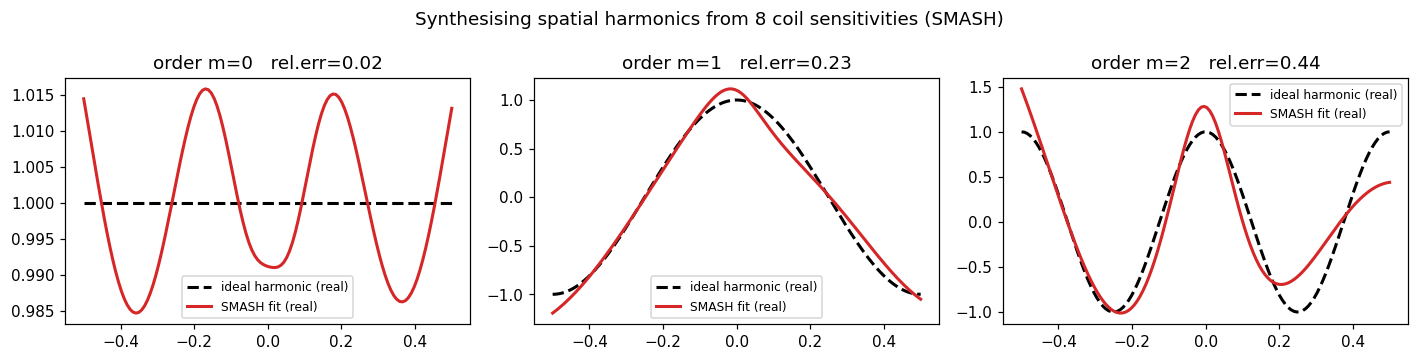

In [4]:
y = np.linspace(-0.5, 0.5, N)              # normalised position along phase-encode
C_profiles = C[:, :, N // 2]               # sensitivity profile of each coil along y (central column)

def fit_smash_weights(C_profiles, m):
    "Least-squares weights so that sum_l w_l C_l(y) ~ exp(-i*2*pi*m*y)."
    target = np.exp(-1j * 2 * np.pi * m * y)
    w, *_ = np.linalg.lstsq(C_profiles.T, target, rcond=None)
    return w, target

fig, ax = plt.subplots(1, 3, figsize=(13, 3.3))
for j, m in enumerate([0, 1, 2]):
    w, target = fit_smash_weights(C_profiles, m)
    synth = w @ C_profiles
    ax[j].plot(y, target.real, "k--", lw=2, label="ideal harmonic (real)")
    ax[j].plot(y, synth.real,  "C3",  lw=2, label="SMASH fit (real)")
    err = np.linalg.norm(synth - target) / np.linalg.norm(target)
    ax[j].set_title(f"order m={m}   rel.err={err:.2f}"); ax[j].legend(fontsize=8)
plt.suptitle("Synthesising spatial harmonics from 8 coil sensitivities (SMASH)")
plt.tight_layout(); plt.show()

**What you should see / the catch.** The $m=0$ (flat) harmonic is easy. As $m$ grows, the fit gets worse —
you need coils whose linear combinations can produce ever-faster sinusoids, and that depends entirely on the
array geometry. This is exactly the lecture's handwritten remark: *"it's impossible — why? because it's not
easy to build a coil to make exactly these signals."* SMASH also produces **one combined image**, so it can't
do a proper sum-of-squares combine.

GRAPPA fixes both problems: it works **coil-by-coil** (so you keep all channels for a clean SoS combine) and it
fits **local k-space neighbourhoods** instead of demanding a global harmonic — far more forgiving.

## 4 · GRAPPA — coil-by-coil k-space interpolation

The idea (slides 29–34): a **missing** k-space point in coil $j$ is a **linear combination of the acquired
neighbours from *all* coils**:

$$ \underbrace{T}_{\text{targets}} \;=\; \underbrace{S}_{\text{sources}}\; \underbrace{w}_{\text{GRAPPA weights}} $$

* **Source point** = a small $k_h \times k_w$ block of acquired points, stacked over all $N_c$ coils → length $n_k n_c$.
* **Target** = the missing point(s), one value per coil → length $n_c$.

**Two stages:**

**(1) Calibration.** From a fully-sampled **Auto-Calibration Signal (ACS)** region (centre of k-space) we already
*know* both sources and targets. Slide the kernel over the ACS to collect many `(S, T)` example pairs, then solve
the least-squares system for the weights:

$$ w = (S^{H}S)^{-1} S^{H} T \qquad\text{(we add Tikhonov regularisation for stability).} $$

**(2) Synthesis + recon.** Apply those weights to the **undersampled** data to fill every missing line, coil by
coil. IFFT each coil, then sum-of-squares combine. No coil maps ever needed.

The matrix shapes (lecture slide 33–34, with $R=2$, kernel $2{\times}3$, $N_c=8$): with $n_b$ calibration blocks,
$S$ is $(n_b \times n_k n_c)=(n_b\times 48)$, $T$ is $(n_b\times n_c)=(n_b\times 8)$, and the weights $w$ are
$(n_k n_c \times n_c) = (48\times 8)$.

In [5]:
def grappa(kspace_us, acs, R, kh=2, kw=3, lam=1e-3, verbose=False):
    # GRAPPA for 1-D (phase-encode) Cartesian undersampling.
    #   kspace_us : (Nc, Ny, Nx) zero-filled undersampled k-space; acquired lines at 0, R, 2R, ...
    #   acs       : (Nc, Nacs, Nx) fully-sampled calibration block (centre of k-space).
    #   R         : acceleration factor.   kh, kw : kernel height (#source lines) x width (along kx).
    #   lam       : Tikhonov regularisation (fraction of mean eigenvalue).
    #   returns   : filled (Nc, Ny, Nx) k-space.
    Nc, Ny, Nx = kspace_us.shape
    src_off = (np.arange(kh) - (kh // 2 - 1)) * R   # source k_y offsets (grid units)
    kx_off  = np.arange(kw) - (kw // 2)             # kernel offsets along k_x
    tgt_offs = np.arange(1, R)                       # missing lines inside the central gap

    # ---------- (1) Calibration: gather (source, target) pairs from the ACS ----------
    Nacs = acs.shape[1]
    base = -src_off.min(); top = src_off.max()
    S_rows = []; T_rows = {t: [] for t in tgt_offs}
    for yy in range(base, Nacs - top):
        for xx in range(kw // 2, Nx - kw // 2):
            src = acs[:, yy + src_off[:, None], (xx + kx_off)[None, :]]   # (Nc, kh, kw)
            S_rows.append(src.reshape(-1))
            for t in tgt_offs:
                T_rows[t].append(acs[:, yy + t, xx])
    S = np.asarray(S_rows)                                                 # (n_b, n_k*n_c)

    # Tikhonov-regularised normal equations:  w = (S^H S + lam I)^-1 S^H T
    StS = S.conj().T @ S
    reg = lam * (np.trace(StS).real / StS.shape[0]) * np.eye(StS.shape[0])
    pinv = np.linalg.inv(StS + reg) @ S.conj().T
    W = {t: pinv @ np.asarray(T_rows[t]) for t in tgt_offs}                # each (n_k*n_c, n_c)
    if verbose:
        print(f"  S:{S.shape}  T:({S.shape[0]},{Nc})  w:{W[tgt_offs[0]].shape}  (n_b={S.shape[0]})")

    # ---------- (2) Synthesis: fill the missing lines ----------
    out = kspace_us.copy()
    for a in range(0, Ny, R):                       # anchor on each acquired line
        s_lines = a + src_off
        if s_lines.min() < 0 or s_lines.max() >= Ny:
            continue
        for xx in range(kw // 2, Nx - kw // 2):
            src = kspace_us[:, s_lines[:, None], (xx + kx_off)[None, :]].reshape(-1)
            for t in tgt_offs:
                if a + t < Ny:
                    out[:, a + t, xx] = src @ W[t]
    return out

Now run the full pipeline and look at every stage for $R=2$:

  S:(2772, 48)  T:(2772,8)  w:(48, 8)  (n_b=2772)


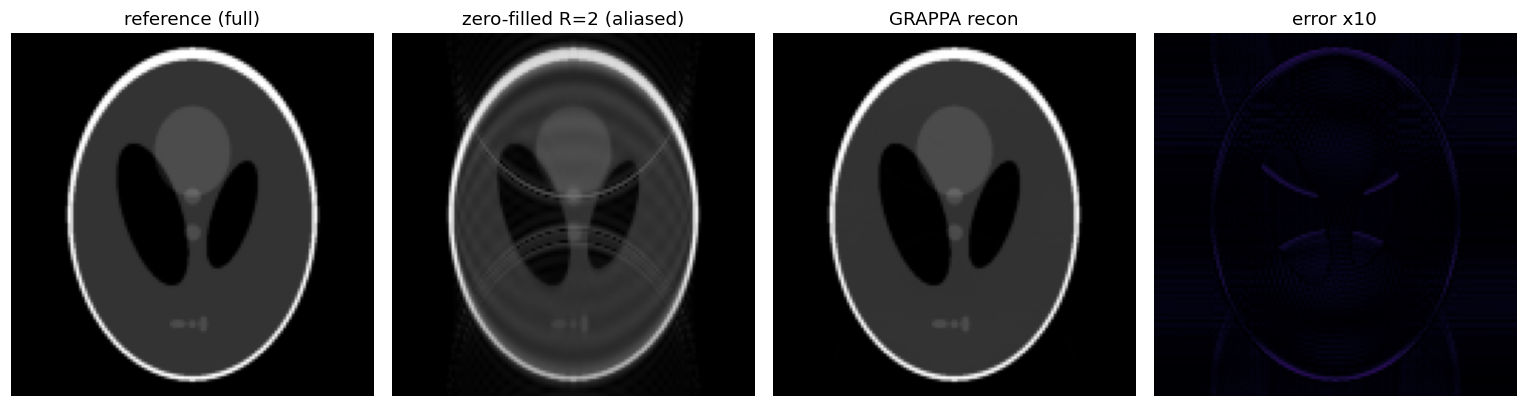

GRAPPA  PSNR=51.73  SSIM=0.982
zero-fill PSNR=26.15


In [6]:
def undersample(ksp_full, R, nacs):
    "Return (zero-filled undersampled k-space, ACS block). ACS lines are also kept in the data."
    us = np.zeros_like(ksp_full)
    us[:, ::R, :] = ksp_full[:, ::R, :]
    c0 = ksp_full.shape[1] // 2 - nacs // 2
    acs = ksp_full[:, c0:c0 + nacs, :]
    us[:, c0:c0 + nacs, :] = acs            # ACS is fully sampled within the acquisition
    return us, acs

R, nacs = 2, 24
us, acs = undersample(ksp_full, R, nacs)
filled = grappa(us, acs, R, kh=2, kw=3, verbose=True)

zf_img    = sos(ifft2c(us))            # zero-filled (aliased)
grappa_img = sos(ifft2c(filled))       # GRAPPA reconstructed

fig, ax = plt.subplots(1, 4, figsize=(14, 3.6))
ax[0].imshow(ref);                ax[0].set_title("reference (full)")
ax[1].imshow(zf_img);             ax[1].set_title(f"zero-filled R={R} (aliased)")
ax[2].imshow(grappa_img);         ax[2].set_title("GRAPPA recon")
ax[3].imshow(np.abs(nrm(ref) - nrm(grappa_img)), cmap="inferno"); ax[3].set_title("error x10")
ax[3].images[0].set_clim(0, 0.1)
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

print(f"GRAPPA  PSNR={psnr(nrm(ref), nrm(grappa_img), data_range=1):.2f}  SSIM={ssim(nrm(ref), nrm(grappa_img), data_range=1):.3f}")
print(f"zero-fill PSNR={psnr(nrm(ref), nrm(zf_img), data_range=1):.2f}")

## 5 · The whole story in one figure (R = 2, 3, 4)
Acceleration trades scan time for SNR and residual artefact. Watch the error climb with $R$.

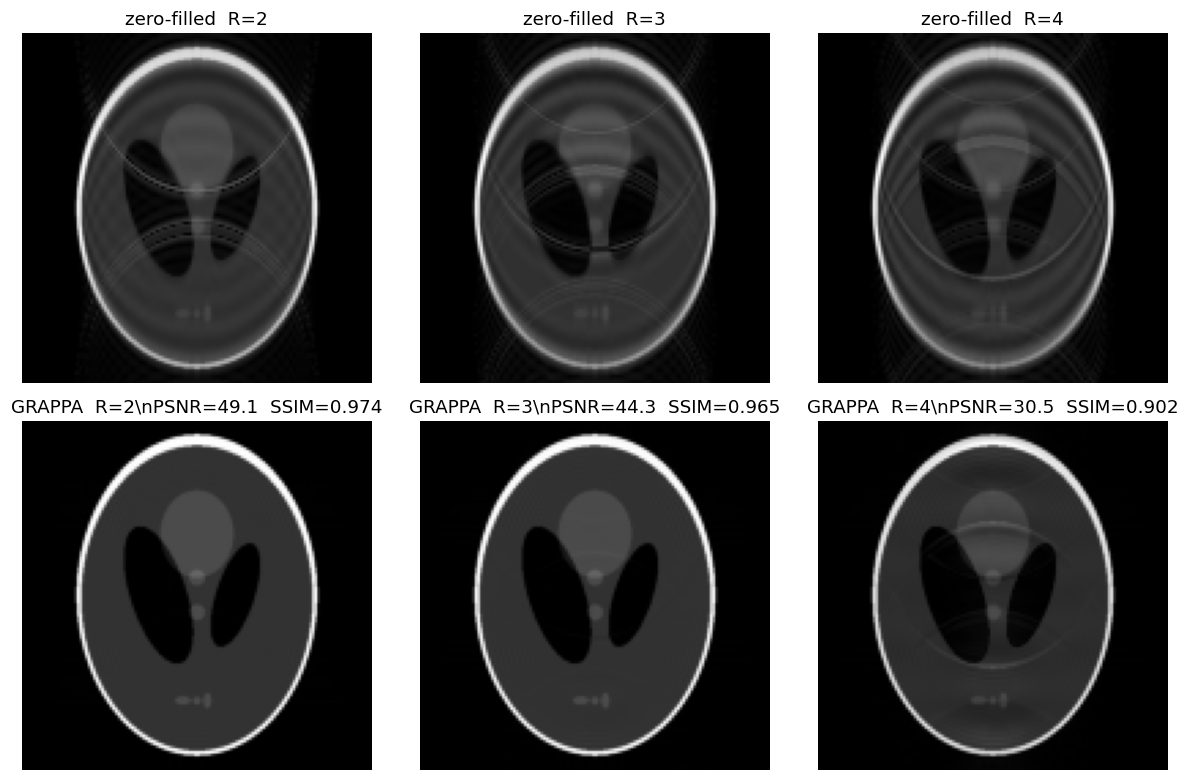

In [7]:
fig, ax = plt.subplots(2, 3, figsize=(11, 7.2))
for j, R in enumerate([2, 3, 4]):
    us, acs = undersample(ksp_full, R, 24)
    rec = sos(ifft2c(grappa(us, acs, R, kh=4, kw=5)))
    zf  = sos(ifft2c(us))
    ax[0, j].imshow(zf);  ax[0, j].set_title(f"zero-filled  R={R}")
    ax[1, j].imshow(rec); ax[1, j].set_title(f"GRAPPA  R={R}\\nPSNR={psnr(nrm(ref),nrm(rec),data_range=1):.1f}  SSIM={ssim(nrm(ref),nrm(rec),data_range=1):.3f}")
for a in ax.ravel(): a.axis("off")
plt.tight_layout(); plt.show()

## 6 · Lab 6 exercise — worked through, with answers

> *From the lecture's exercise slide.* Reconstruct regularly-undersampled 8-coil data with GRAPPA and study how
> **acceleration $R$**, **kernel size**, and **ACS lines** affect quality (PSNR & SSIM vs. the fully-sampled
> reference), then compare to **SENSE**. We use the synthetic 8-coil data above in place of `data_brain_8coils.mat`.

A small helper to score any setting:

In [8]:
def evaluate(R, kh, kw, nacs, ksp=ksp_full):
    us, acs = undersample(ksp, R, nacs)
    rec = sos(ifft2c(grappa(us, acs, R, kh=kh, kw=kw)))
    return (psnr(nrm(ref), nrm(rec), data_range=1),
            ssim(nrm(ref), nrm(rec), data_range=1), rec)

### 6a · Effect of acceleration $R \in \{2,3,4\}$  (kernel 2×3, 24 ACS)

In [9]:
print(f"{'R':>3} | {'PSNR':>6} | {'SSIM':>5}")
for R in [2, 3, 4]:
    p, s, _ = evaluate(R, 2, 3, 24)
    print(f"{R:>3} | {p:6.2f} | {s:5.3f}")

  R |   PSNR |  SSIM
  2 |  51.73 | 0.982
  3 |  45.34 | 0.963


  4 |  39.06 | 0.928


**Answer.** PSNR and SSIM **fall monotonically as $R$ rises**. Two reasons: (i) fewer measured lines means
each missing point is extrapolated further, and (ii) **noise amplification** — the *g-factor*. Where coil
sensitivities overlap strongly the linear system is ill-conditioned, so noise blows up locally (the grainy,
spatially-varying noise you see at $R=4$ in the lecture's example images). $R$ can never exceed $N_c$, and useful
$R$ is well below that.

### 6b · Effect of kernel size $\in \{2{\times}3,\,4{\times}5,\,6{\times}7\}$  (R=3, 24 ACS)

In [10]:
print(f"{'kernel':>7} | {'PSNR':>6} | {'SSIM':>5}")
for kh, kw in [(2, 3), (4, 5), (6, 7)]:
    p, s, _ = evaluate(3, kh, kw, 24)
    print(f"{kh}x{kw:<4} | {p:6.2f} | {s:5.3f}")

 kernel |   PSNR |  SSIM
2x3    |  45.34 | 0.963
4x5    |  44.27 | 0.965


6x7    |  32.11 | 0.915


**Answer.** A *moderately* larger kernel uses more neighbours and can model the k-space convolution better.
But the number of unknown weights is $n_k n_c \times n_c$, which **grows fast** with kernel size. With only 24
ACS lines there are too few calibration blocks to fit a $6{\times}7$ kernel — the normal equations become
ill-conditioned and the fit **overfits the calibration noise**, so quality *drops*. The kernel size is a
bias–variance knob: too small underfits the convolution, too large overfits the limited calibration data.

### 6c · Effect of ACS lines $\in \{12,24,36,48\}$  (R=3, kernel 4×5)

In [11]:
print(f"{'ACS':>4} | {'PSNR':>6} | {'SSIM':>5}")
for nacs in [12, 24, 36, 48]:
    p, s, _ = evaluate(3, 4, 5, nacs)
    print(f"{nacs:>4} | {p:6.2f} | {s:5.3f}")

 ACS |   PSNR |  SSIM
  12 |  25.72 | 0.790
  24 |  44.27 | 0.965


  36 |  45.70 | 0.970
  48 |  46.22 | 0.976


**Answer.** More ACS lines = more `(S, T)` example pairs = a **better-conditioned, more accurate** weight fit,
so quality rises and then plateaus. The **trade-off**: ACS lines are *acquired*, so they **eat into your
acceleration** — the *effective* acceleration is always lower than the nominal $R$. The joint trade-off with
kernel size: a large kernel *demands* a large ACS region to stay well-posed (rule of thumb: keep #calibration
blocks comfortably larger than $n_k n_c$). Choose the smallest ACS + kernel that gives acceptable artefacts.

### 6d · GRAPPA vs SENSE  (R ∈ {2,3,4})

In [12]:
def sense_recon(ksp_full, C, R):
    "Textbook 1-D SENSE: unfold the R-fold aliased pixels using known coil maps."
    Nc, Ny, Nx = ksp_full.shape
    us = np.zeros_like(ksp_full); us[:, ::R, :] = ksp_full[:, ::R, :]
    aliased = ifft2c(us) * R                       # (Nc, Ny, Nx), scaled
    out = np.zeros((Ny, Nx), dtype=np.complex128)
    for x in range(Nx):
        for yy in range(Ny // R):
            rows = (yy + np.arange(R) * (Ny // R)) % Ny   # pixels folded together
            Cmat = C[:, rows, x]                           # (Nc, R) sensitivity matrix
            a = aliased[:, yy, x]                           # (Nc,) measured aliased pixel
            rho, *_ = np.linalg.lstsq(Cmat, a, rcond=None)  # unfold
            out[rows, x] = rho
    return np.abs(out)

print(f"{'R':>3} | {'GRAPPA PSNR':>11} {'SSIM':>6} | {'SENSE PSNR':>10} {'SSIM':>6}")
for R in [2, 3, 4]:
    pg, sg, _ = evaluate(R, 4, 5, 32)
    se = sense_recon(ksp_full, C, R)
    ps, ss = psnr(nrm(ref), nrm(se), data_range=1), ssim(nrm(ref), nrm(se), data_range=1)
    print(f"{R:>3} | {pg:11.2f} {sg:6.3f} | {ps:10.2f} {ss:6.3f}")

  R | GRAPPA PSNR   SSIM | SENSE PSNR   SSIM


  2 |       49.58  0.977 |     318.01  1.000


  3 |       45.46  0.968 |      22.17  0.893


  4 |       40.21  0.954 |     304.78  1.000


**Answer / discussion (matches the lecture summary, slides 36–38).**

* With **perfect, noise-free coil maps** (as simulated here) SENSE is essentially optimal and often edges out
  GRAPPA — consistent with the lecturer's *"if you can, use SENSE."*
* **GRAPPA's real-world advantages:** it needs **no explicit coil-sensitivity estimation** (a major source of
  SENSE error when maps are wrong), the small kernel acts as **implicit regularisation**, and it is **more robust
  to inconsistencies** between calibration and imaging data. That is why GRAPPA is so widely deployed
  (particularly on Siemens scanners).
* **GRAPPA's costs:** less flexible — sensitive to calibration-region size, kernel size, and **sampling
  geometry**. It is simple for 1-D acceleration (one weight set works everywhere) but cumbersome for 2-D or
  irregular/non-Cartesian sampling, where each geometry needs its own kernel (slide 37).

### 6 · Bonus — *"Will the calibration step work well?"* (slide 33)
With a tiny ACS (e.g. the lecture's 4×4) and kernel $2{\times}3$, $N_c=8$, the weight matrix has
$n_k n_c \times n_c = 48 \times 8$ unknowns but you can extract only a handful of calibration blocks ($n_b$ is
small). Then $S^{H}S$ (size $48\times48$) has rank $\le n_b \ll 48$ — it is **singular / not invertible**, so the
unregularised fit is unstable. That is precisely the lecturer's note *"it's not invertible."* The fixes are the
ones we used: **more ACS lines** and **Tikhonov regularisation** (`lam`). Try it: 

In [13]:
print(f"{'lam':>8} | {'PSNR (R=3, 6x7, acs24)':>22}")
for lam in [0.0, 1e-4, 1e-2]:
    us, acs = undersample(ksp_full, 3, 24)
    rec = sos(ifft2c(grappa(us, acs, 3, kh=6, kw=7, lam=lam)))
    print(f"{lam:>8} | {psnr(nrm(ref), nrm(rec), data_range=1):>22.2f}")

     lam | PSNR (R=3, 6x7, acs24)
     0.0 |                  12.13


  0.0001 |                  36.83
    0.01 |                  27.97


## 7 · (Optional) Run it on the real lab data
Everything above is data-agnostic. To use the lab's real `data_brain_8coils.mat`:

```python
from scipy.io import loadmat
mat = loadmat("data_brain_8coils.mat")          # adjust the key to the file's variable name
coil_imgs = np.transpose(mat["DATA"], (2, 0, 1)) # -> (Nc, Ny, Nx)  complex coil images
ksp_full  = fft2c(coil_imgs)
ref        = sos(ifft2c(ksp_full))
# ...then call undersample(...) / grappa(...) / evaluate(...) exactly as above.
```
For raw scanner k-space, try the **fastMRI** multi-coil dataset (`*.h5`, read with `h5py`). The only thing that
changes is how you *load* `ksp_full`; the GRAPPA code is identical.

## 8 · Self-test (answers in `C06_summary.md`)
1. In one sentence each, state the difference between SENSE and GRAPPA in terms of **when the IFFT happens**.
2. *Multiplication in image space = ? in k-space.* Why does that make GRAPPA a **local** k-space operation?
3. What is the **ACS** region and what are the **source** and **target** matrices used for?
4. Write the GRAPPA weight equation and give the shapes of $S$, $T$, $w$ for $R=2$, kernel $2{\times}3$, $N_c=8$.
5. Why does image quality fall as $R$ grows? Name the quantity that captures the noise amplification.
6. Give one advantage and one disadvantage of GRAPPA relative to SENSE.
7. Why is GRAPPA awkward for non-Cartesian / 2-D acceleration?

**You can now:** implement GRAPPA end-to-end, reason about its parameters, and compare it to SENSE — the goal of
Module 4, Day 26. Next up (Day 27): non-Cartesian parallel imaging & iterative reconstruction.